### Astrostatistic Lecture 19

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from astroML.utils import completeness_contamination
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

data = pd.read_csv('/home/ricca/astrostat/astrostatistics_bicocca_2026/solutions/galaxyquasar.csv') #load data
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [4]:
#unpack the data into arrays
z = data['z'].values
u = data['u'].values
g = data['g'].values
r = data['r'].values
i = data['i'].values
z = data['z'].values
cls = data['class'].values
Target=[]
for nome in range(len(cls)):       #for a galaxy 0 quasar 1, target is the correct answer
    if cls[nome] == 'GALAXY':
        Target.append(0)
    else:
        Target.append(1)

#arrays for the color combinations
u_g = u - g
g_r = g - r
r_i = r - i
i_z = i - z

staring_x = np.array([u_g, g_r, r_i, i_z]).T #array for the color combinations (features)

For the Gaussian Naive Bayes 
Accuracy score: 0.973900
Completeness: 0.924370
Contamination: 0.103870


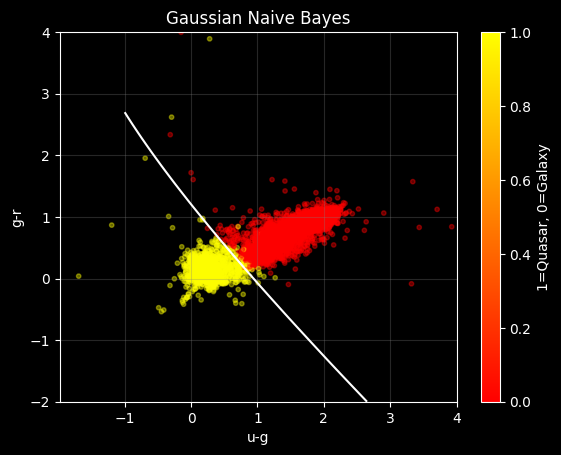

For the Linear Discriminant Analysis 
Accuracy score: 0.980800
Completeness: 0.925070
Contamination: 0.060455


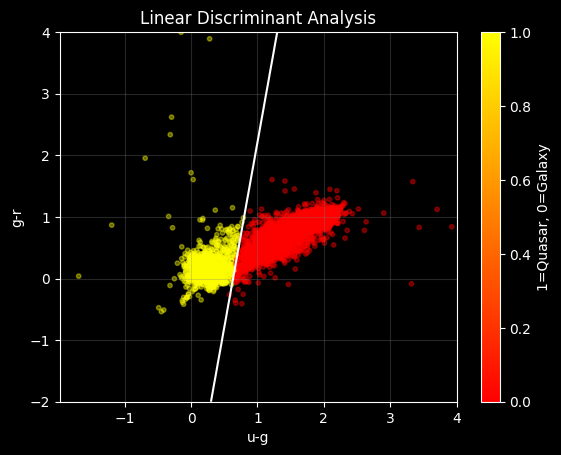

For the Linear Discriminant Analysis 
Accuracy score: 0.979200
Completeness: 0.920868
Contamination: 0.067376


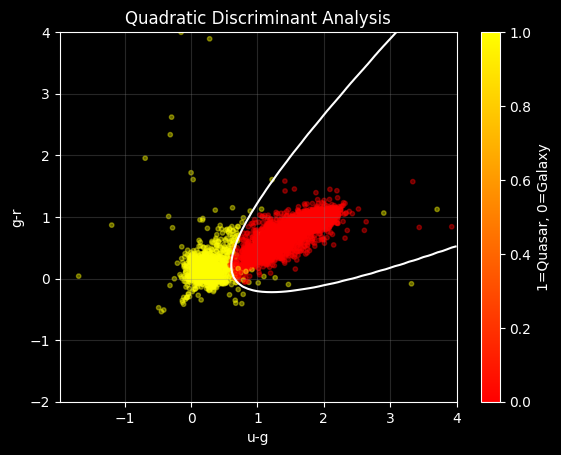

For the Gaussian Mixtures Models 
Accuracy score: 0.970300
Completeness: 0.934874
Contamination: 0.132554


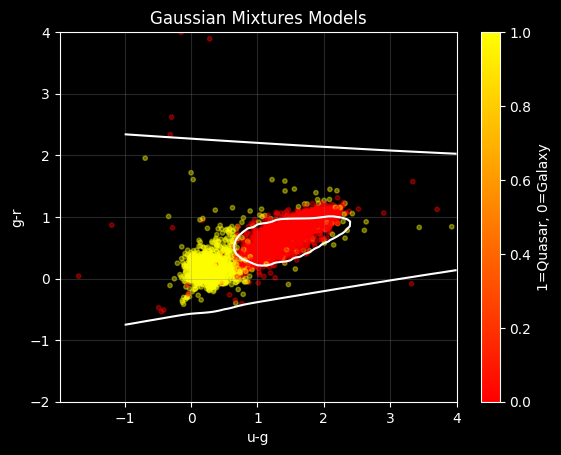

For the k-NN classifier 
Accuracy score: 0.985300
Completeness: 0.937675
Contamination: 0.041518


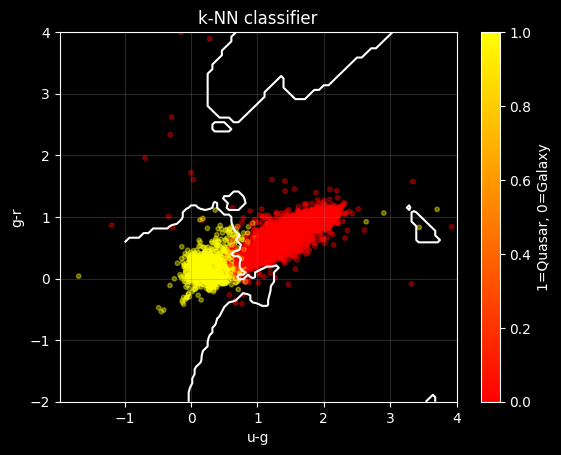

NOTE: all borders are rough because they are a 2D representation of a 4D space


In [64]:
#now we train al algorithm to predict the target, but first we split
X_train, X_test, y_train, y_test = train_test_split(staring_x, Target, test_size=0.2, random_state=42)

#create a grid of points for the borders
xx, yy = np.meshgrid(np.linspace(-1, 4, 71),
                     np.linspace(-2, 4, 81))   
X_grid = np.c_[
    xx.ravel(),
    yy.ravel(),
    np.full(xx.size, np.mean(X_train[:, 2])),
    np.full(xx.size, np.mean(X_train[:, 3]))
]

#first we use a Gaussian Naive Bayes classifier
gnb = GaussianNB()
gnb.fit(X_train,y_train)
gnb_predictions = gnb.predict(X_test)
gnb_completeness, gnb_contamination = completeness_contamination(gnb_predictions, y_test)
print('For the Gaussian Naive Bayes \nAccuracy score: %f' % gnb.score(X_test, y_test))
print('Completeness: %f' % gnb_completeness)
print('Contamination: %f' % gnb_contamination)

#try to visualize this (all data are in magnitude units)
Z_gnb = gnb.predict_proba(X_grid)[:, 1]
Z_gnb = Z_gnb.reshape(xx.shape)
ab = plt.scatter(X_test[:, 0], X_test[:, 1], c=gnb_predictions, s=10, cmap='autumn')
ab.set_alpha(0.4)
plt.title('Gaussian Naive Bayes')
cbar_0 = plt.colorbar(ab, label='1=Quasar, 0=Galaxy')
cbar_0.solids.set_alpha(1)
plt.contour(xx, yy, Z_gnb, levels=[0.5], colors='white')
plt.xlabel('u-g')
plt.ylabel('g-r')
plt.grid(color='grey', alpha=0.3)
plt.show()

#the second process we can use is Linear or Quadratic Discriminant Analisys
lda = LDA()
lda.fit(X_train,y_train)
lda_pred = lda.predict(X_test)
lda_completeness, lda_contamination = completeness_contamination(lda_pred, y_test)
print('For the Linear Discriminant Analysis \nAccuracy score: %f' % lda.score(X_test, y_test))
print('Completeness: %f' % lda_completeness)
print('Contamination: %f' % lda_contamination)

Z_lda = lda.predict_proba(X_grid)[:, 1]
Z_lda = Z_lda.reshape(xx.shape)
cd = plt.scatter(X_test[:, 0], X_test[:, 1], c=lda_pred, s=10, cmap='autumn')
cd.set_alpha(0.4)
plt.title('Linear Discriminant Analysis')
cbar_1 = plt.colorbar(cd, label='1=Quasar, 0=Galaxy')
cbar_1.solids.set_alpha(1)
plt.contour(xx, yy, Z_lda, levels=[0.5], colors='white')
plt.xlabel('u-g')
plt.ylabel('g-r')
plt.grid(color='grey', alpha=0.3)
plt.show()

qda = QDA()
qda.fit(X_train,y_train)
qda_pred = qda.predict(X_test)
qda_completeness, qda_contamination = completeness_contamination(qda_pred, y_test)
print('For the Linear Discriminant Analysis \nAccuracy score: %f' % qda.score(X_test, y_test))
print('Completeness: %f' % qda_completeness)
print('Contamination: %f' % qda_contamination)

Z_qda = qda.predict_proba(X_grid)[:, 1]
Z_qda = Z_qda.reshape(xx.shape)
sc=plt.scatter(X_test[:, 0], X_test[:, 1], c=qda_pred, s=10, cmap='autumn')
sc.set_alpha(0.4)
cbar = plt.colorbar(sc, label='1=Quasar, 0=Galaxy')
plt.contour(xx, yy, Z_qda, levels=[0.5], colors='white')
plt.title('Quadratic Discriminant Analysis')
cbar.solids.set_alpha(1)
plt.xlabel('u-g')
plt.ylabel('g-r')
plt.grid(color='grey', alpha=0.3)
plt.show()

#the third way is using Gaussian Mixtures Models
gmmb = GMMBayes(3) #in theory i think i'll need to cross validate this number
gmmb.fit(X_train,y_train)
gmmb_pred = gmmb.predict(X_test)
gmmb_completeness, gmmb_contamination = completeness_contamination(gmmb_pred, y_test)
print('For the Gaussian Mixtures Models \nAccuracy score: %f' % gmmb.score(X_test, y_test))
print('Completeness: %f' % gmmb_completeness)
print('Contamination: %f' % gmmb_contamination)

Z_gmmb = gmmb.predict_proba(X_grid)[:, 1]
Z_gmmb = Z_gmmb.reshape(xx.shape)
ef = plt.scatter(X_test[:, 0], X_test[:, 1], c=gmmb_pred, s=10, cmap='autumn')
ef.set_alpha(0.4)
plt.title('Gaussian Mixtures Models')
plt.contour(xx, yy, Z_gmmb, levels=[0.5], colors='white')
cbar = plt.colorbar(ef, label='1=Quasar, 0=Galaxy')
cbar.solids.set_alpha(1)
plt.xlabel('u-g')
plt.ylabel('g-r')
plt.grid(color='grey', alpha=0.3)
plt.show()

#finally a k-NN classifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
knn_pred = knn.predict(X_test)
knn_completeness, knn_contamination = completeness_contamination(knn_pred, y_test)
print('For the k-NN classifier \nAccuracy score: %f' % knn.score(X_test, y_test))
print('Completeness: %f' % knn_completeness)
print('Contamination: %f' % knn_contamination)

Z_knn = knn.predict_proba(X_grid)[:, 1]
Z_knn = Z_knn.reshape(xx.shape)
fg = plt.scatter(X_test[:, 0], X_test[:, 1], c=knn_pred, s=10, cmap='autumn')
fg.set_alpha(0.4)
plt.title('k-NN classifier')
plt.contour(xx, yy, Z_knn, levels=[0.5], colors='white')
cbar = plt.colorbar(fg, label='1=Quasar, 0=Galaxy')
cbar.solids.set_alpha(1)
plt.xlabel('u-g')
plt.ylabel('g-r')   
plt.grid(color='grey', alpha=0.3)
plt.show()
print('NOTE: all borders are rough because they are a 2D representation of a 4D space')

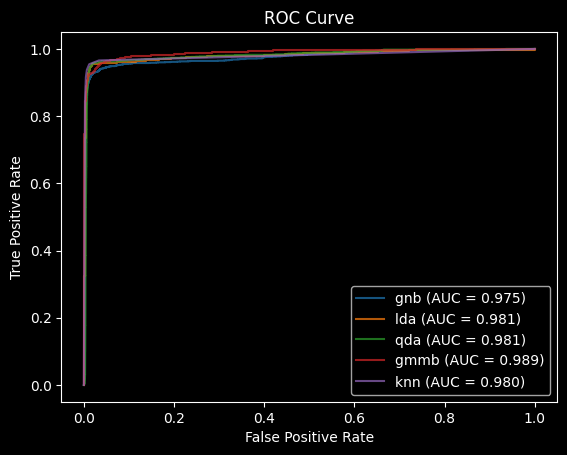

In [65]:
plt.figure()
models = {
    'gnb': gnb,
    'lda': lda,
    'qda': qda,
    'gmmb': gmmb,
    'knn': knn
}

for name, model in models.items():      #for every model we used before we calculate the ROC curve
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', alpha=0.7)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()